# Рабочая тетрадь по ПСИИ №8

## Выполнил: студент группы БФБО-06-24 Петров Артем

---

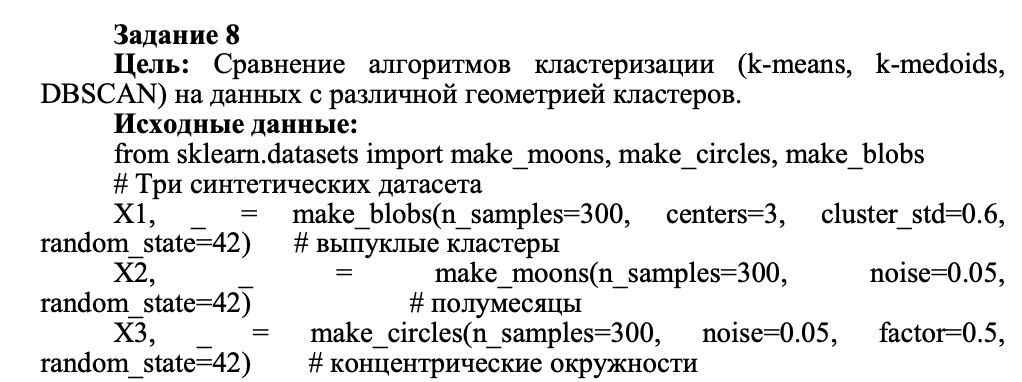

In [9]:
from sklearn.datasets import make_moons, make_circles, make_blobs
# Три синтетических датасета
# Выпуклые кластеры
X1, _ = make_blobs(n_samples = 300, centers = 3, cluster_std = 0.6, random_state = 42)
# полумесяцы
X2, _ = make_moons(n_samples = 300, noise = 0.05, random_state = 42)
# концентрические окружности
X3, _ = make_circles(n_samples = 300, noise = 0.05, factor = 0.5, random_state = 42)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


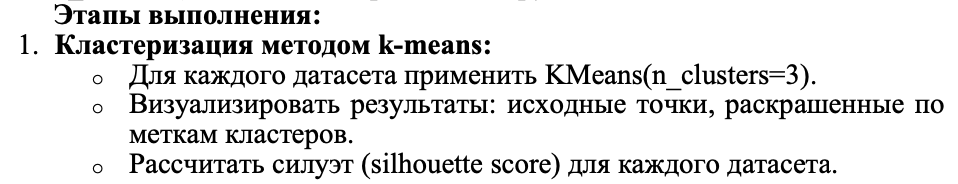

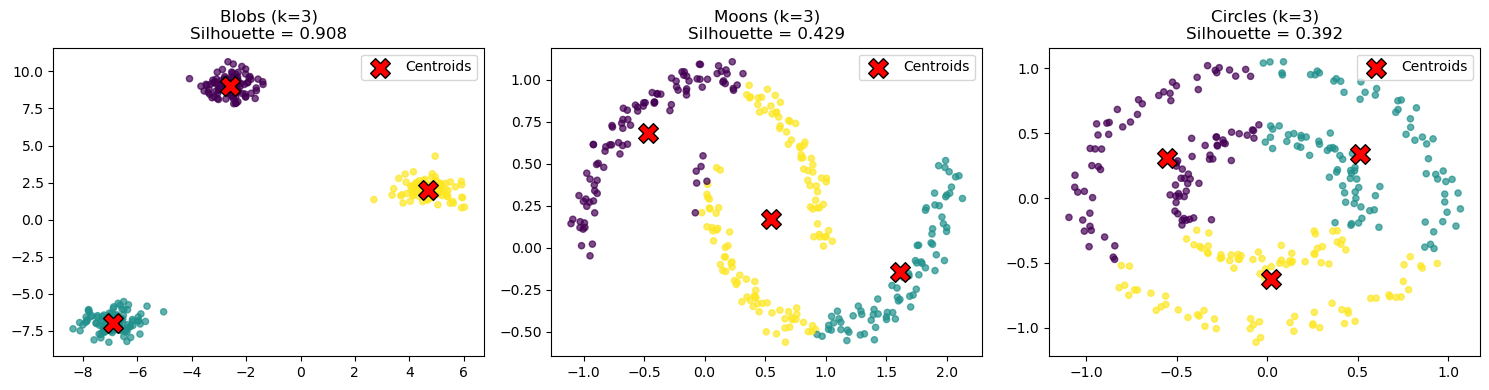

Silhouette scores: X1=0.908, X2=0.429, X3=0.392


In [10]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Для компактности и удобства была создана функция создания предсказания и графиков, 
# которая выдаёт на выходе значение силуета:
def plot_kmeans(X, title, ax):
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    silhouette = silhouette_score(X, labels)
    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=20, alpha=0.7)
    ax.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
               marker='X', s=200, c='red', edgecolors='black', label='Centroids')
    ax.set_title(f'{title}\nSilhouette = {silhouette:.3f}')
    ax.legend()
    return silhouette

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sil1 = plot_kmeans(X1, 'Blobs (k=3)', axes[0])
sil2 = plot_kmeans(X2, 'Moons (k=3)', axes[1])
sil3 = plot_kmeans(X3, 'Circles (k=3)', axes[2])
plt.tight_layout()
plt.show()

print(f'Silhouette scores: X1={sil1:.3f}, X2={sil2:.3f}, X3={sil3:.3f}')

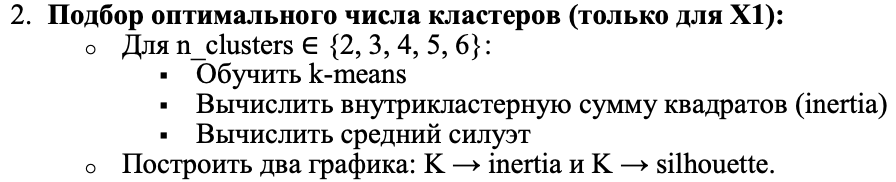

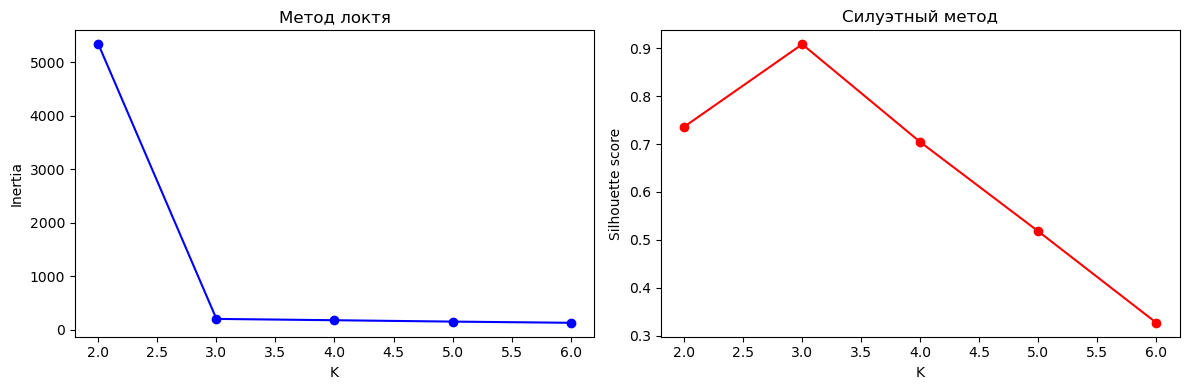

In [20]:
inertias = []
silhouettes = []
K_range = range(2, 7)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X1)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X1, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(K_range, inertias, 'bo-')
ax1.set_xlabel('K')
ax1.set_ylabel('Inertia')
ax1.set_title('Метод локтя')

ax2.plot(K_range, silhouettes, 'ro-')
ax2.set_xlabel('K')
ax2.set_ylabel('Silhouette score')
ax2.set_title('Силуэтный метод')
plt.tight_layout()
plt.show()

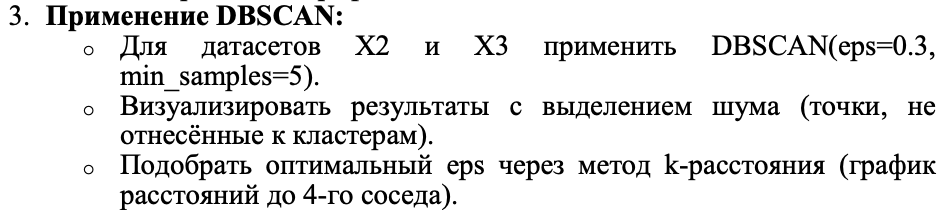

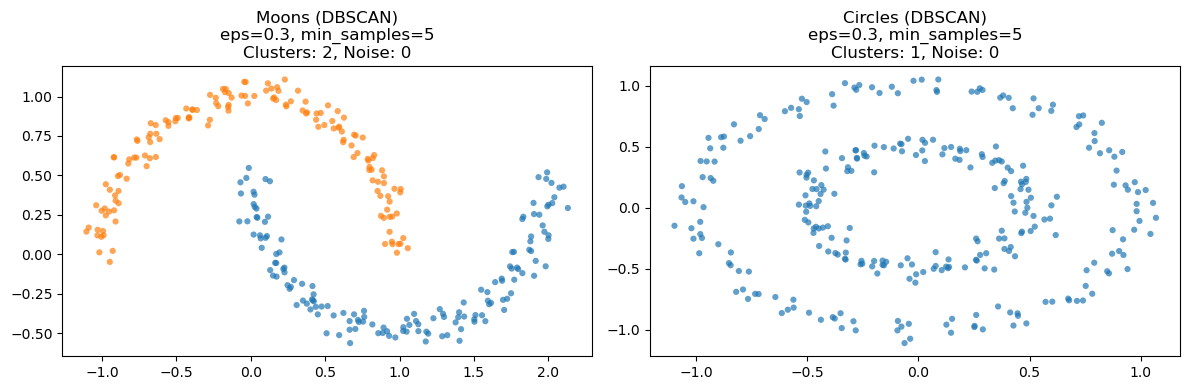

In [14]:
from sklearn.cluster import DBSCAN

def plot_dbscan(X, title, eps, min_samples, ax):
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    # Цвет: шум – серым
    unique_labels = set(labels)
    colors = [plt.cm.tab10(i) for i in range(len(unique_labels))]
    for k, col in zip(unique_labels, colors):
        if k == -1:
            col = 'red'
        class_member_mask = (labels == k)
        ax.scatter(X[class_member_mask, 0], X[class_member_mask, 1],
                   c=[col], s=20, alpha=0.7, edgecolors='none')
    ax.set_title(f'{title}\neps={eps}, min_samples={min_samples}\n'
                 f'Clusters: {n_clusters}, Noise: {n_noise}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_dbscan(X2, 'Moons (DBSCAN)', eps=0.3, min_samples=5, ax=axes[0])
plot_dbscan(X3, 'Circles (DBSCAN)', eps=0.3, min_samples=5, ax=axes[1])
plt.tight_layout()
plt.show()

График k-расстояния для X2 (Moons):


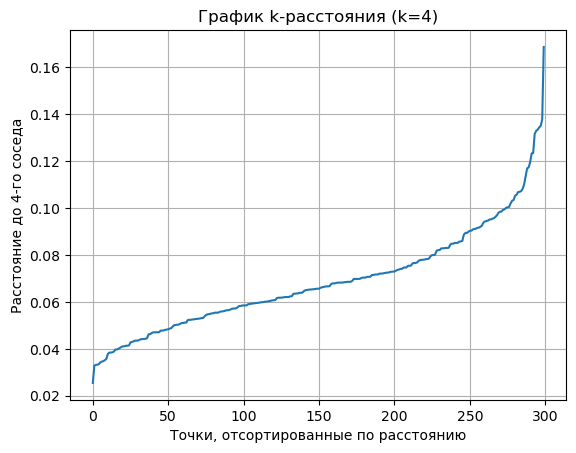

График k-расстояния для X3 (Circles):


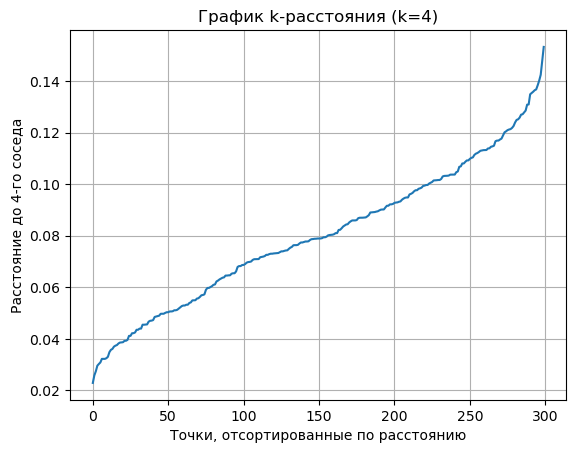

In [17]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

def plot_k_distance(X, k=4):
    neigh = NearestNeighbors(n_neighbors=k)
    nbrs = neigh.fit(X)
    distances, indices = nbrs.kneighbors(X)
    k_dist = np.sort(distances[:, k-1])  # расстояние до k-го соседа
    plt.plot(k_dist)
    plt.xlabel('Точки, отсортированные по расстоянию')
    plt.ylabel(f'Расстояние до {k}-го соседа')
    plt.title(f'График k-расстояния (k={k})')
    plt.grid(True)
    plt.show()

print("График k-расстояния для X2 (Moons):")
plot_k_distance(X2, k=4)
print("График k-расстояния для X3 (Circles):")
plot_k_distance(X3, k=4)

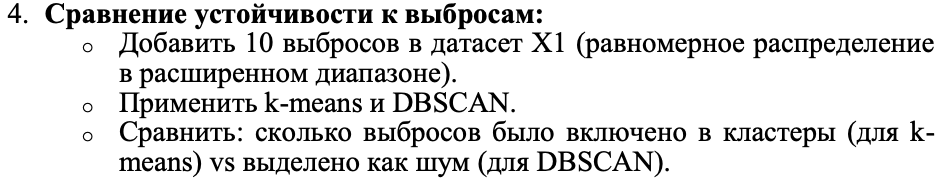

In [19]:
# Добавляем выбросы
np.random.seed(42)
outliers = np.random.uniform(low=-5, high=5, size=(10, 2))
X1_out = np.vstack([X1, outliers])

# K-means
kmeans_out = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_kmeans = kmeans_out.fit_predict(X1_out)

# DBSCAN
dbscan_out = DBSCAN(eps=0.5, min_samples=5)  
labels_dbscan = dbscan_out.fit_predict(X1_out)

# Подсчёт: для k-means – сколько выбросов попало в кластеры (все)
outliers_in_clusters = sum(1 for i in range(len(X1), len(X1_out)) if labels_kmeans[i] != -1)
# для DBSCAN – сколько выбросов помечено как шум
outliers_noise_db = sum(1 for i in range(len(X1), len(X1_out)) if labels_dbscan[i] == -1)

print(f'K-means: выбросы в кластерах = {outliers_in_clusters}/10')
print(f'DBSCAN: выбросы как шум = {outliers_noise_db}/10')

K-means: выбросы в кластерах = 10/10
DBSCAN: выбросы как шум = 10/10


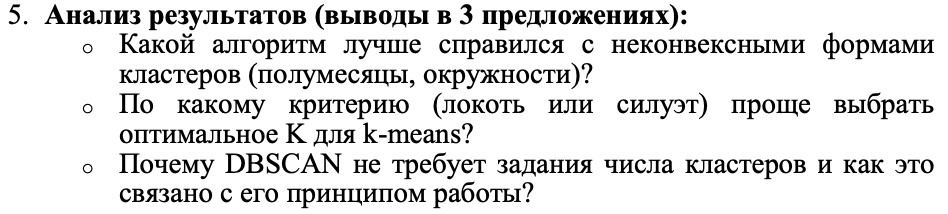

### Какой алгоритм лучше справился с неконвексными формами кластеров (полумесяцы, окружности)?

DBSCAN показал идеальное разделение полумесяцев и окружностей, тогда как K‑means на этих формах дал ошибочные «сферические» кластеры.

### По какому критерию (локоть или силуэт) проще выбрать оптимальное K, для K-means?

Силуэтный метод даёт более чёткий и однозначный максимум, тогда как метод локтя часто требует субъективного определения «излома».

### Почему DBSCAN не требует задания числа кластеров и как это связано с его принципом работы?

потому что он строит кластеры на основе плотности: он объединяет точки, достижимые друг из друга через цепочки соседей в радиусе eps. Число кластеров определяется автоматически, как количество связных компонент в графе плотности.